# MNIST coarse/local MST grid

Compare hierarchical graph settings on a stratified sample of 8,000 real MNIST images. Each cell shows the 2D embedding for one coarse/local MST setting; points are colored by digit class.


In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'

import sys
from pathlib import Path
from IPython.display import display

repo_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'mst_embedding').is_dir()),
    None,
)
if repo_root is not None:
    for path in (repo_root, repo_root / 'notebooks'):
        if str(path) not in sys.path:
            sys.path.insert(0, str(path))

from hierarchical_quality_utils import run_mnist_parameter_grid

# MNIST sample and reference graph.
N_INSTANCES = 8_000
DATA_SEED = 42
MODEL_SEED = 42
N_MSTS = 8
N_EPOCHS = 200
N_CLUSTERS = 100

# Rows are N_COARSE_MSTS; columns are N_LOCAL_MSTS.
N_COARSE_MSTS_VALUES = (2, 3, 4, 8)
N_LOCAL_MSTS_VALUES = (2, 3, 4, 8)
N_JOBS = -1

parameter_grid, exact_reference, embeddings, digit_labels = run_mnist_parameter_grid(
    coarse_mst_values=N_COARSE_MSTS_VALUES,
    local_mst_values=N_LOCAL_MSTS_VALUES,
    max_samples=N_INSTANCES,
    data_seed=DATA_SEED,
    model_seed=MODEL_SEED,
    n_msts=N_MSTS,
    n_epochs=N_EPOCHS,
    n_clusters=N_CLUSTERS,
    n_jobs=N_JOBS,
)

display(exact_reference)
display(parameter_grid)


Fixed MNIST grid data: 8,000 samples × 784 features; coarse values=(2, 3, 4, 8); local values=(2, 3, 4, 8)


{'unique_edges': 63992,
 'trustworthiness': 0.9065715808754462,
 '5NN_accuracy': 0.863875,
 'graph_construction_seconds': 12.260623209003825,
 'embedding_optimization_seconds': 5.547911208996084,
 'fit_time_seconds': 17.840351582999574,
 'wall_time_seconds': 17.840992875018856}

,n_coarse_msts,n_local_msts,effective_coarse_msts,unique_edges,exact_edge_precision,exact_edge_recall,trustworthiness,5NN_accuracy,delta_trustworthiness,delta_5NN_accuracy,delta_fit_time_seconds,graph_construction_seconds,embedding_optimization_seconds,fit_time_seconds,wall_time_seconds
0,2,2,2,20441,0.946236,0.302257,0.890842,0.766500,-0.015730,-0.097375,-15.550705,0.503704,1.783931,2.289646,2.289690
1,2,3,2,31254,0.907436,0.443196,0.911226,0.801000,0.004654,-0.062875,-15.013937,0.432022,2.382982,2.826414,2.826446
2,2,4,2,42426,0.860769,0.570681,0.908579,0.792250,0.002008,-0.071625,-13.907730,0.490467,3.438314,3.932621,3.932650
3,2,8,2,89794,0.603648,0.847043,0.903929,0.788375,-0.002643,-0.075500,-10.305166,0.675652,6.855501,7.535186,7.535207
4,3,2,3,21722,0.940107,0.319118,0.880331,0.765375,-0.026241,-0.098500,-15.463805,0.527541,1.847352,2.376547,2.376567
5,3,3,3,33344,0.898482,0.468168,0.892217,0.776000,-0.014354,-0.087875,-14.423214,0.565688,2.847669,3.417138,3.417165
6,3,4,3,45483,0.848251,0.602903,0.895368,0.766125,-0.011204,-0.097750,-13.755839,0.632456,3.448233,4.084512,4.084529
7,3,8,3,98120,0.581258,0.891252,0.900990,0.784750,-0.005582,-0.079125,-7.663555,2.054244,8.116314,10.176797,10.176824
8,4,2,4,22664,0.932889,0.330401,0.864329,0.740625,-0.042243,-0.123250,-15.427208,0.629942,1.779831,2.413144,2.413161
9,4,3,4,34927,0.888825,0.485123,0.884394,0.773375,-0.022178,-0.090500,-14.169748,0.721631,2.930408,3.670604,3.670665


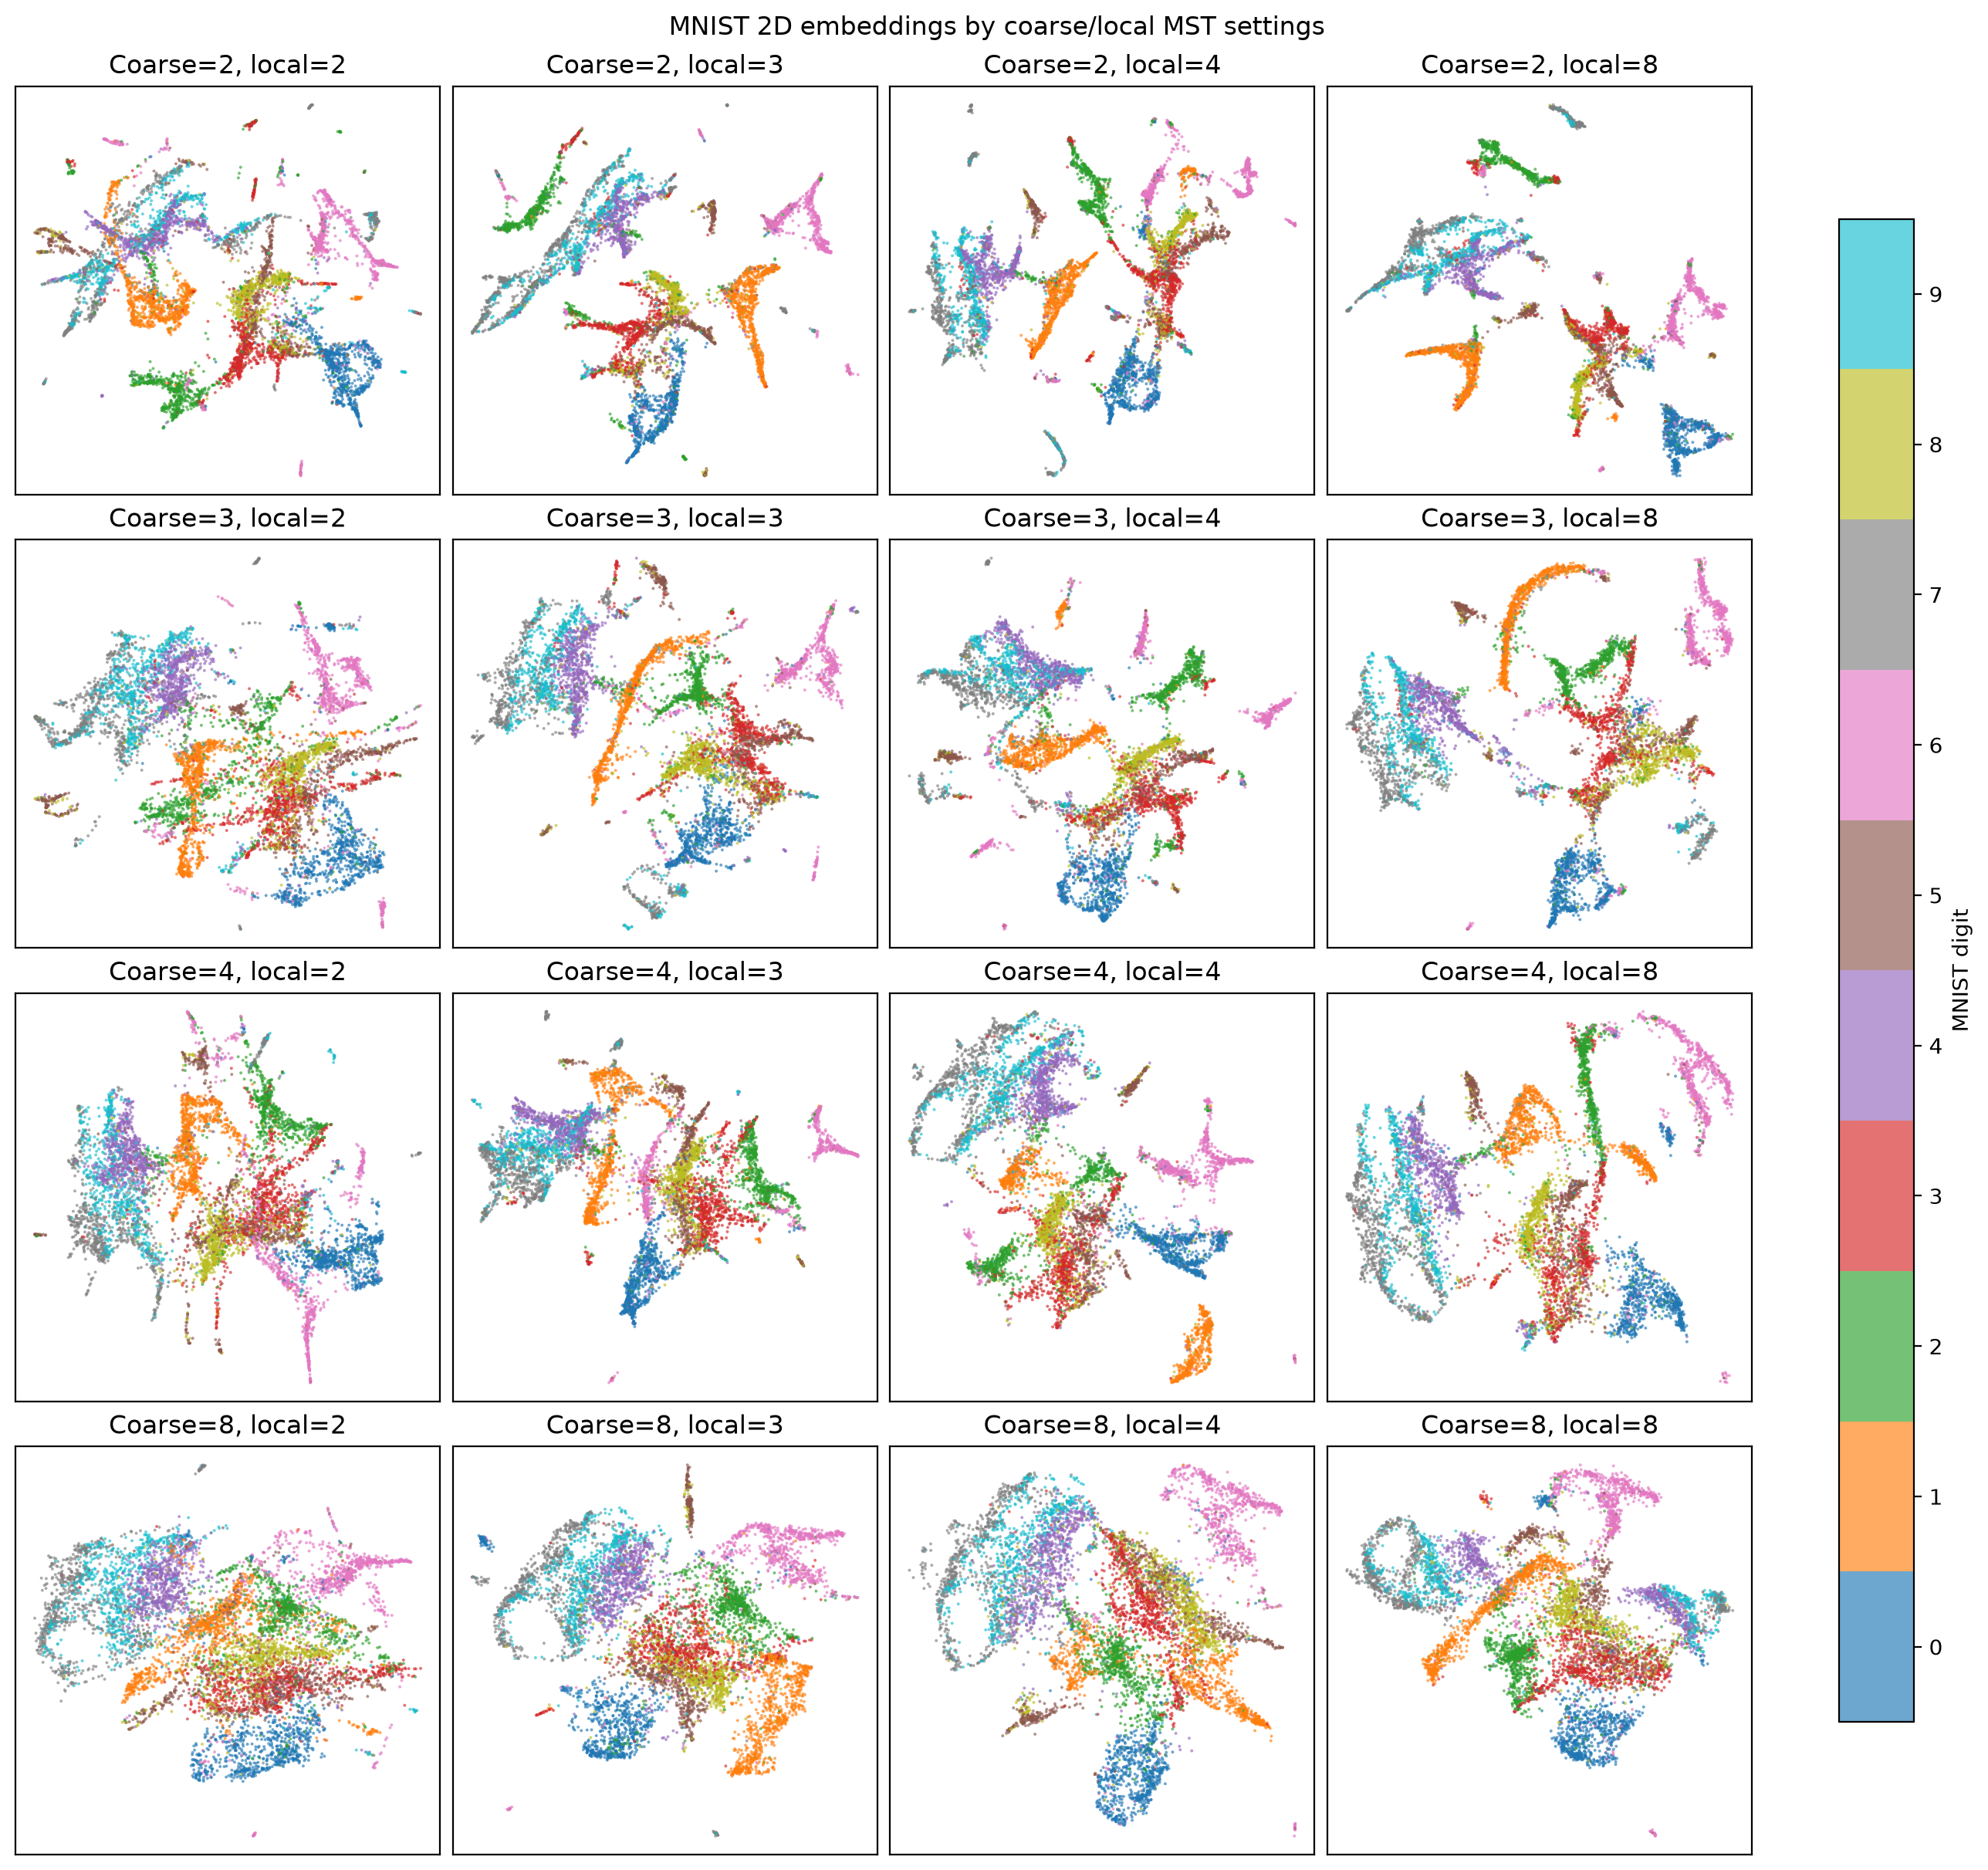

In [2]:
from hierarchical_quality_utils import plot_mnist_embedding_grid

grid_figure = plot_mnist_embedding_grid(
    embeddings,
    digit_labels,
    coarse_mst_values=N_COARSE_MSTS_VALUES,
    local_mst_values=N_LOCAL_MSTS_VALUES,
)
grid_figure
